<img src="./img/uomlogo.png" align="left"/><br><br>
# PHYS20762 - Project - Damped Harmonic Oscillator

Tasks completed by 
11301011
March 2025

We first initialise our Python interpreter and prepare the constants that will be used throughout.

In [1]:
# Initialisation
import string
from math import *
import numpy as np
from scipy.optimize import fsolve
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import random
import cmath

plt.rcParams.update({'font.size': 14})
plt.style.use('default')

In [2]:
#Parameters
k = 0.55 #kg/s**2 
m = 4.13 #kg
b = 0.08 #in kg/s

#Initial conditions
x0 = 0 # in m
v0 = -1 # in m/s

# Duration that we are integrating
T = 150

# Choose a range of step sizes (in s)
h = (0.005, 0.01, 0.05, 0.1)

## Abstract

In this simulation, various numerical methods were used to solve the damped harmonic oscillator differential equation. Firstly, the analytical solution was plotted, and then compared to the Euler method, Improved Euler Method, the Verlet method and finally, the Euler-Cromer method. This required adjusting step sizes and simulation length to evaluate which method provided the best simulation. The best method was found to be the verlet method, and this was implemented in various scenarios relating to the damped oscillator.

## Introduction

Simple Harmonic Motion describes the oscilaltory behaviour of springs. It is presented as a second order linear diffrential equation, and describes the motion of systems such as a mass on a spring, pendulum, and LC circuits. While this assumes that there is no energy lost, the damped oscillator introduces energy loss and driving forces to describe the behaviour. These have more real-life applications, and can take factors like air resistance and drag into account of the behaviour of the system. 

While these have analytical formulations, the analysis of this motion with realistic values require computational methods to quantify the behaviour of such spring systems. Hence, in this project, various numerical integration methods will be explored. 

## Theory

### Damped Harmonic Oscillation
This project will explore the damped harmonic oscillator. This requires an equation that utilises  $\frac{d^2x}{dt^2}$, $\frac{dx}{dt}$, and x, which are acceleration, velocity and dispalcement respectively: 

$$ m \frac{d^2 x}{dt^2} + b \frac{dx}{dt} + kx = F(t). $$

In this equation, m is the mass of the object, b is the damping coefficient, which quantifies the resistance that opposes the motion, k is the spring coefficient and F(t) is the force applied into the system. For this project, the value of $k = 0.55 kg/s^2$ and $m = 4.13kg$ will be used. We will begin by defining the analytic solutions for the oscillator for position, velocity and energy. 


In [3]:
def Analytic(x0, v0, time):
    # Constants
    A = (b / (2 *1j*cmath.sqrt(4 * k * m - b ** 2)) + 1 / 2) * x0 + v0 * m / (1j * cmath.sqrt(4 * k * m - b ** 2)) 
    B = x0 - A
     
    # Equation
    X = np.exp(-b* time / (2 * m)) * (A * np.exp(1j * cmath.sqrt(4 * k * m - b ** 2) * time / (2 * m))
                                     + B * np.exp(-1j * cmath.sqrt(4 * k * m - b ** 2) * time / (2 * m)))
    return X

def Analytic_velocity(x0, v0, time):
     # Constants
    A = (b/(2*1j*cmath.sqrt(4*k*m-b**2))+1/2)*x0 + v0*m/(cmath.sqrt(4*k*m-b**2)*1j) 
    B = x0 - A
    
    X = np.exp(-b*time/(2*m)) * (A*np.exp(1j*cmath.sqrt(4*k*m-b**2)*time/(2*m))
                                +B*np.exp(-1j*cmath.sqrt(4*k*m-b**2)*time/(2*m)))
    
    # Velocity V = dX/dt
    omega = cmath.sqrt(4*k*m - b**2) / (2*m)
    V = np.exp(-b*time/(2*m)) * (
        A * (1j * omega) * np.exp(1j * omega * time) +
        B * (-1j * omega) * np.exp(-1j * omega * time)
    ) - (b / (2*m)) * X
    
    return V

In [4]:
def Analytic_energy(x0, v0, time):
    # Constants
    damping_factor = b / m
    omega = cmath.sqrt(k / m - (b ** 2) / (4 * m ** 2))
    
    A = (b / (2 * 1j * cmath.sqrt(4 * k * m - b ** 2)) + 1 / 2) * x0 + v0 * m / (1j * cmath.sqrt(4 * k * m - b ** 2))
    B = x0 - A
    
    #Equation for position
    X = np.exp(-b * time / (2 * m)) * (
        A * np.exp(1j * cmath.sqrt(4 * k * m - b ** 2) * time / (2 * m)) +
        B * np.exp(-1j * cmath.sqrt(4 * k * m - b ** 2) * time / (2 * m))
    ) 
    
    #Equation for velocity
    V = np.exp(-damping_factor * time / 2) * (
        np.exp(1j * omega * time) * A * ((-damping_factor / 2) + 1j * omega) +
        np.exp(-1j * omega * time) * B * ((-damping_factor / 2) - 1j * omega)
    )
    
    #Sum of elastic and kinetic energy
    total_energy = 0.5 * k * X ** 2 + 0.5 * m * V ** 2
    return total_energy

## Attempting Approximations

### Method 1: Euler Method
The first method that will be used is the Euler Method, which utilises an initial value and forward differences to find an approximation for a derivative. These require initial values for x and v (formerly written as $dx/dt$), and will iterate as 

$$x_{i+1} = x_i + v_i h$$
$$v_{i+1} = v_i + a_i h$$

in which i symbolises the iteration, and h is the step size, which indicates how much time is incremented in each iteration. Consequently, equation (1) can be represented as

$$a_i = -\frac{b}{m} v_i - \frac{k}{m} x_i. $$

The benefit of this method is the simple implementation and small values of h, which would improve the accurracy of the integration. However, there is a linear reduction in error as the step size, h, is decreased. This means that the error decreases slowly, which means that the accuracy is decreased when the step size is small. Thus, other methods that are computationally more efficient is used, which is the strength of the other methods. 

Each of the following sections will show the code for a method, and then in the end, the plots will be shown alongside a comparison.

In [5]:
# The method implementation
def EulerMethod(x0, v0, nsteps, hstep):
     # Preparing zeroed arrays of x, v and E which are position, velocity and energy respectively
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)
    E = np.zeros(nsteps)
    
    # Assign initial conditions
    x[0] = x0 
    v[0] = v0
    E[0] = 0.5*k*x[0]**2 + 0.5*m*v[0]**2
    for i in range(nsteps-1): #requires -1 since the equation requires i+1 on LHS and i on RHS
        a = -(k/m)*x[i] - (b/m)*v[i]
        x[i+1] = x[i] + v[i]*hstep #in m
        v[i+1] = v[i] + a*hstep #in m/s
        E[i+1] = 0.5*k*x[i+1]**2 + 0.5*m*v[i+1]**2 #in J
        
    return (x, v, E) 


# Finding the solution for the five step sizes defined at the start
for hstep in h:
    # Requires integer number of loops 
    nsteps = int(T/hstep)
    
    # Calling Euler Method Using the various hsteps
    (x, v, E) = EulerMethod(x0, v0, nsteps, hstep)

#Saving the energy obtained from this method
E_Euler = E

### Method 2: Improved Euler's Method

This method adds a term to account by adding a term from the Taylor expansion to account for the error. This results in 

$$
    x_{i+1} = x_i + hv_i + \frac{h^2}{2} a_i
$$

$$
    v_{i+1} = v_i + ha_i ,
$$

with the key difference being the third term on the right handside of the position equation. 


In [6]:
def ImprovedEulerMethod(x0, v0, nsteps, hstep):
    # Preparing zeroed arrays of x, v and E which are position, velocity and energy respectively 
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)
    E = np.zeros(nsteps)
    
    # Assign initial conditions as before
    x[0] = x0 
    v[0] = v0
    E[0] = 0.5*k*x[0]**2 + 0.5*m*v[0]**2   #Sum of elastic energy and kinetic energy, in joules
    
    for i in range(nsteps-1): #requires -1 since the equation requires i+1 on LHS and i on RHS
        a = -(k/m)*x[i] - (b/m)*v[i]
        x[i+1] = x[i] + v[i]*hstep + 1/2*(hstep**2)*a #here we have the added term to account for the error
        v[i+1] = v[i] + a*hstep #in m/s 
        E[i+1] = 0.5*k*x[i+1]**2 + 0.5*m*v[i+1]**2
        
    return (x, v, E) 

# Finding the solution for a range of step sizes 
for hstep in h:
    nsteps = int(T/hstep)
    # Calling the Improved euler method for the five hsteps
    (x, v, E) = ImprovedEulerMethod(x0, v0, nsteps, hstep)

#Saving the energy obtained from this method 
E_Euler_Improved = E

### Method 3: Verlet's Method

This method requires the use of a quartic version of $h$, which requires additional computational power but provides more accuracy. This starts with the same equation for $a_i$ as before, but has modified equations for $v$ and $x$ as follows,

$$
    v_i = \frac{x_{i+1} - x_{i-1}}{2h}.
$$

However, what is contained within $x$ is different:

$$
    A =  \frac{4m - 2kh^2}{D}
$$

$$
    B = \frac{bh - 2m}{D}
$$

$$
    D = 2m + bh
$$

This method requires the first term to be defined, so Improved-Euler is used to begin the algorithm. In other cases, this can be done by having a first guess, which is used in methods such as the Newton-Raphson method. 

In [7]:
def VerletsMethod(x0, v0, nsteps, hstep):
    # Preparing zeroed arrays of x, v and E which are position, velocity and energy respectively 
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)
    E = np.zeros(nsteps)
    
    # Assign initial conditions
    x[0] = x0 
    v[0] = v0
    E[0] = 0.5*k*x[0]**2 + 0.5*m*v[0]**2
    
    for i in range(nsteps-1): #requires -1 since the equation requires i+1 on LHS and i on RHS
        D = 2 * m + hstep * b
        A = (4 * m - 2 * k * hstep**2) / D
        B = (b*hstep - 2*m)/D
        
        if i==0: #Separate conditions for 0 since the iterative method requires i+1 and i-1 
            a = - ( k / m ) * x[i] - ( b / m ) * v[i]
            x[i+1] = x[i] + v[i] * hstep + 0.5 * (hstep**2) * a #in m
            v[i+1] = v[i] + a * hstep #in m/s
            E[i+1] = 0.5 * k * x[i+1]**2 + 0.5 * m * v[i+1]**2
            
            
        else:
            x[i+1] = A * x[i] + B * x[i-1]
            v[i] = (x[i+1] - x[i-1]) / (2*hstep)
            E[i+1] = 0.5 * k * x[i]**2 + 0.5 * m * v[i]**2
            
            
    return (x, v, E) 

# Finding the solution for a range of step sizes 
for hstep in h:
    nsteps = int( T / hstep )
    (x, v, E) = VerletsMethod(x0, v0, nsteps, hstep)

#Saving the energy obtained from this method
E_Verlet = E

### Method 4: Euler Cromer Method

The Euler Cromer method returns to the original level of computational simplicity, and uses iterative equations,

$$
 x_{i+1} = x_i + hv_{i+1}
$$

$$
 v_{i+1} = v_i - \frac{hk}{m} x_i
$$

In [8]:
def EulerCromer(x0, v0, nsteps, hstep):
     # Preparing zeroed arrays of x, v and E which are position, velocity and energy respectively 
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)
    E = np.zeros(nsteps)
    
    # Assign initial conditions
    x[0] = x0 
    v[0] = v0
    E[0] = 0.5*k*x[0]**2 + 0.5*m*v[0]**2
    
    for i in range(nsteps-1):
        a = -(k/m)*x[i] - (b/m)*v[i]
        v[i+1] = v[i] + hstep * a       # Update velocity first
        x[i+1] = x[i] + hstep * v[i+1]   # Then update position using the new velocity
        E[i+1] = 0.5*k*x[i+1]**2 + 0.5*m*v[i+1]**2
        
    return (x, v, E) 

# Finding the solution for a range of step sizes 
for hstep in h:
    nsteps = int(T/hstep)
    # call the iterative method 
    (x, v, E) = EulerCromer(x0, v0, nsteps, hstep)

#Saving the energy obtained from this method
E_EulerCromer = E

### Method 5: Runge-Kutta Method

The Runge Kutta method (RK4) converts second order ordinary differential equations into a first order system. This is done by taking four different estimates of the gradient instead of just the one in Euler to allow a better estimation and accuracy prediction. These estimations follow as [1]:

$$
k_1^x = h v_n, k_1^v = h  \frac{1}{m} (F(t_n) - b v_n - k x_n),
$$

$$
k_2^x = h ( v_n + \frac{k_1^v}{2}), k_2^v = h\frac{1}{m}( F(t_n + {h}{2}) - b (v_n +{k_1^v}{2}) - k (x_n + {k_1^x}{2}) ), 
$$

$$
k_3^x = h ( v_n + \frac{k_2^v}{2} ),  k_3^v = h[ \frac{1}{m} ( F(t_n + \frac{h}{2}) - b (v_n + \frac{k_2^v}{2}) - k (x_n + \frac{k_2^x}{2})),
$$

$$
k_4^x = h (v_n + k_3^v),k_4^v = h[ \frac{1}{m}( F(t_n + h) - b (v_n + k_3^v) - k (x_n + k_3^x)).
$$

This is implemented into solutions for x and v as
$$
x_{n+1} = x_n + \frac{1}{6} (k_1^x + 2k_2^x + 2k_3^x + k_4^x)
$$

$$
v_{n+1} = v_n + \frac{1}{6} (k_1^v + 2k_2^v + 2k_3^v + k_4^v).
$$ 

However, this is a computationally taxing method as each iteration requires four steps. We will observe its effectiveness, and ultimately decide whether this strain on the computer is worth its accuracy, or whether the other methods will prove to be sufficient. 

[1] J. C. Butcher, Runge-Kutta Methods for Linear Ordinary Differential Equations, NASA Technical Memorandum 19980228171, NASA Langley Research Center, 1998. [Online]. Available: https://ntrs.nasa.gov/api/citations/19980228171/downloads/19980228171.pdf.



In [9]:
# Runge-Kutta 4th Order Method
def RK4_Method(x0, v0, nsteps, hstep):
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)
    E = np.zeros(nsteps)

    x[0] = x0
    v[0] = v0
    E[0] = 0.5*k*x[0]**2 + 0.5*m*v[0]**2

    for i in range(nsteps - 1):
        
        k1x = v[i]
        k1v = (-k/m) * x[i] - (b/m) * v[i]

        k2x = v[i] + (hstep/2) * k1v
        k2v = (-k/m) * (x[i] + (hstep/2) * k1x) - (b/m) * k2x

        k3x = v[i] + (hstep/2) * k2v
        k3v = (-k/m) * (x[i] + (hstep/2) * k2x) - (b/m) * k3x

        k4x = v[i] + hstep * k3v
        k4v = (-k/m) * (x[i] + hstep * k3x) - (b/m) * k4x

        # Update values
        x[i+1] = x[i] + (hstep/6) * (k1x + 2*k2x + 2*k3x + k4x)
        v[i+1] = v[i] + (hstep/6) * (k1v + 2*k2v + 2*k3v + k4v)
        E[i+1] = 0.5 * k * x[i+1]**2 + 0.5 * m * v[i+1]**2

    return (x, v, E)

# Running the RK4 method for different step sizes
for hstep in h:
    nsteps = int(T / hstep)
    x, v, E = RK4_Method(x0, v0, nsteps, hstep)

# Save the energy obtained from this method
E_RK4 = E


### Plotting

These 5 methods will now be plotted with their various hsteps, then compared between each other for hstep = 0.05 to explore how well they approximate the analytical solution. The first set of plots will compare displacement approximations, and the second will compare that for velocity. 

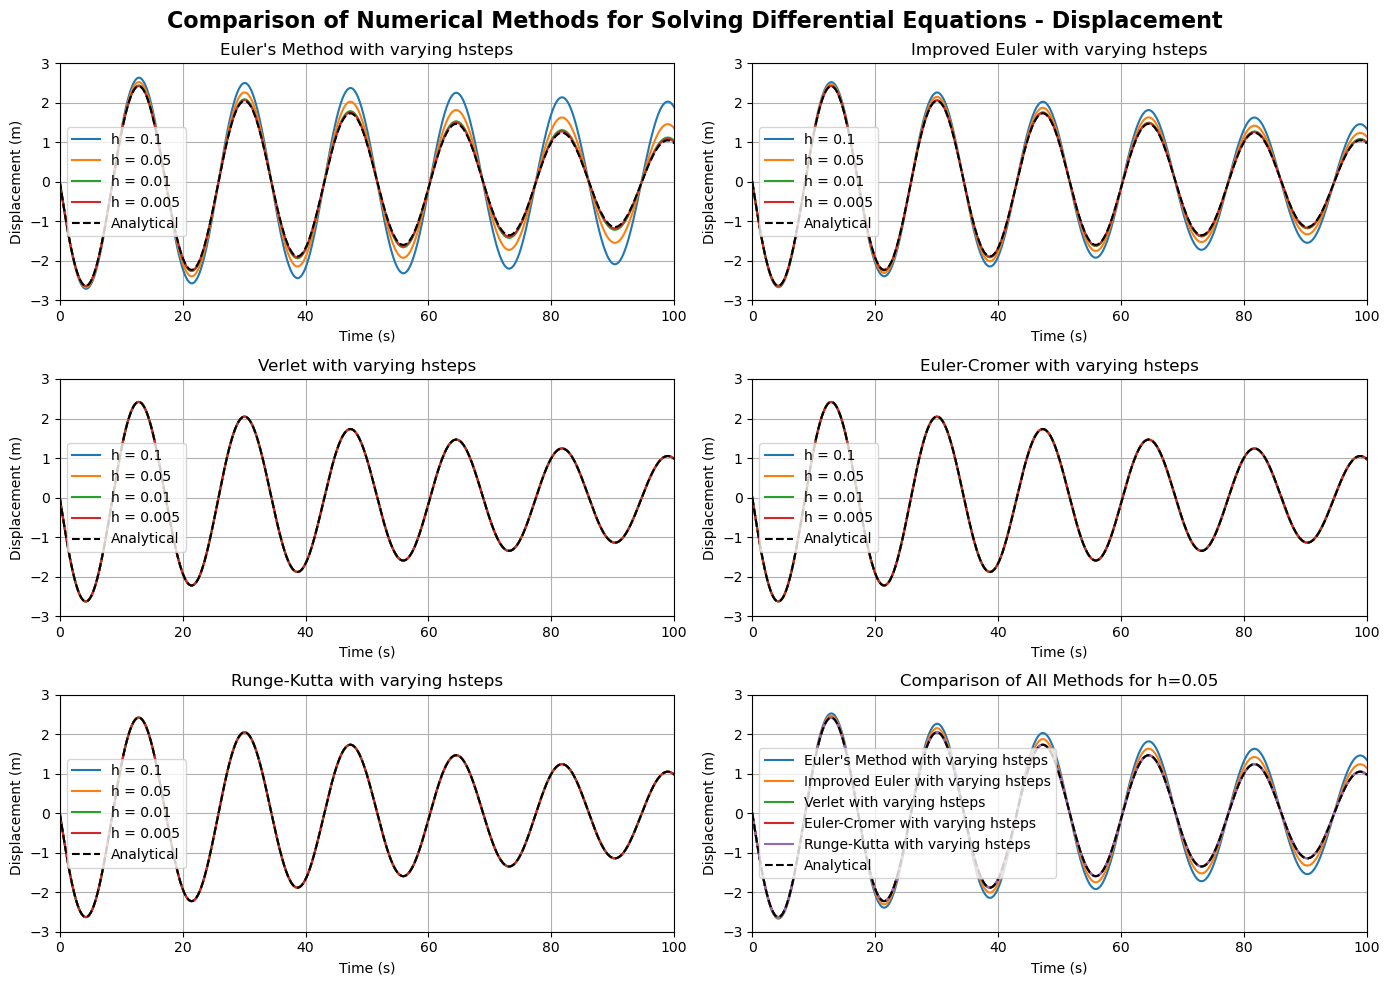

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))  #Setting the layout of the subplots, we have 6 needed
axes = axes.flatten()  #Simplify the iteration
h_values = [0.1, 0.05, 0.01, 0.005] #re-define the hsteps for making a new array 

time_arrays = {h: np.arange(0, T, h) for h in h_values}


methods = {
    "Euler's Method with varying hsteps": EulerMethod,
    "Improved Euler with varying hsteps": ImprovedEulerMethod,
    "Verlet with varying hsteps": VerletsMethod,
    "Euler-Cromer with varying hsteps": EulerCromer,
    "Runge-Kutta with varying hsteps": RK4_Method
}



# Generate and plot each method in its respective subplot
for i, (method_name, method) in enumerate(methods.items()):
    for hstep in h_values:
        nsteps = int(T / hstep)
        x, v, E = method(x0, v0, nsteps, hstep)
        axes[i].plot(np.arange(0, T, hstep), x, label=f"h = {hstep}")
        
        
    axes[i].plot(np.arange(0,T,hstep), Analytic(x0, v0, np.arange(0,T,hstep)).real, "k--", label = "Analytical")
    axes[i].set_title(method_name)
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Displacement (m)")
    axes[i].legend()
    axes[i].set_xlim(0, 100)
    axes[i].set_ylim(-3, 3)
    axes[i].grid()
    
ax_main = axes[-1]
hstep_main = 0.05
nsteps_main = int(T / hstep_main)

for method_name, method in methods.items():
    x, v, E = method(x0, v0, nsteps_main, hstep_main)
    ax_main.plot(time_arrays[hstep_main], x, label=f"{method_name}")

# Add analytical solution outside of initial for loop
ax_main.plot(time_arrays[hstep_main], 
             Analytic(x0, v0, time_arrays[hstep_main]).real, 
             "k--", label="Analytical")

ax_main.set_title("Comparison of All Methods for h=0.05")
ax_main.set_xlabel("Time (s)")
ax_main.set_ylabel("Displacement (m)")
ax_main.legend()
ax_main.set_xlim(0, 100)
ax_main.set_ylim(-3, 3)

fig.suptitle("Comparison of Numerical Methods for Solving Differential Equations - Displacement", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.grid()
plt.show()

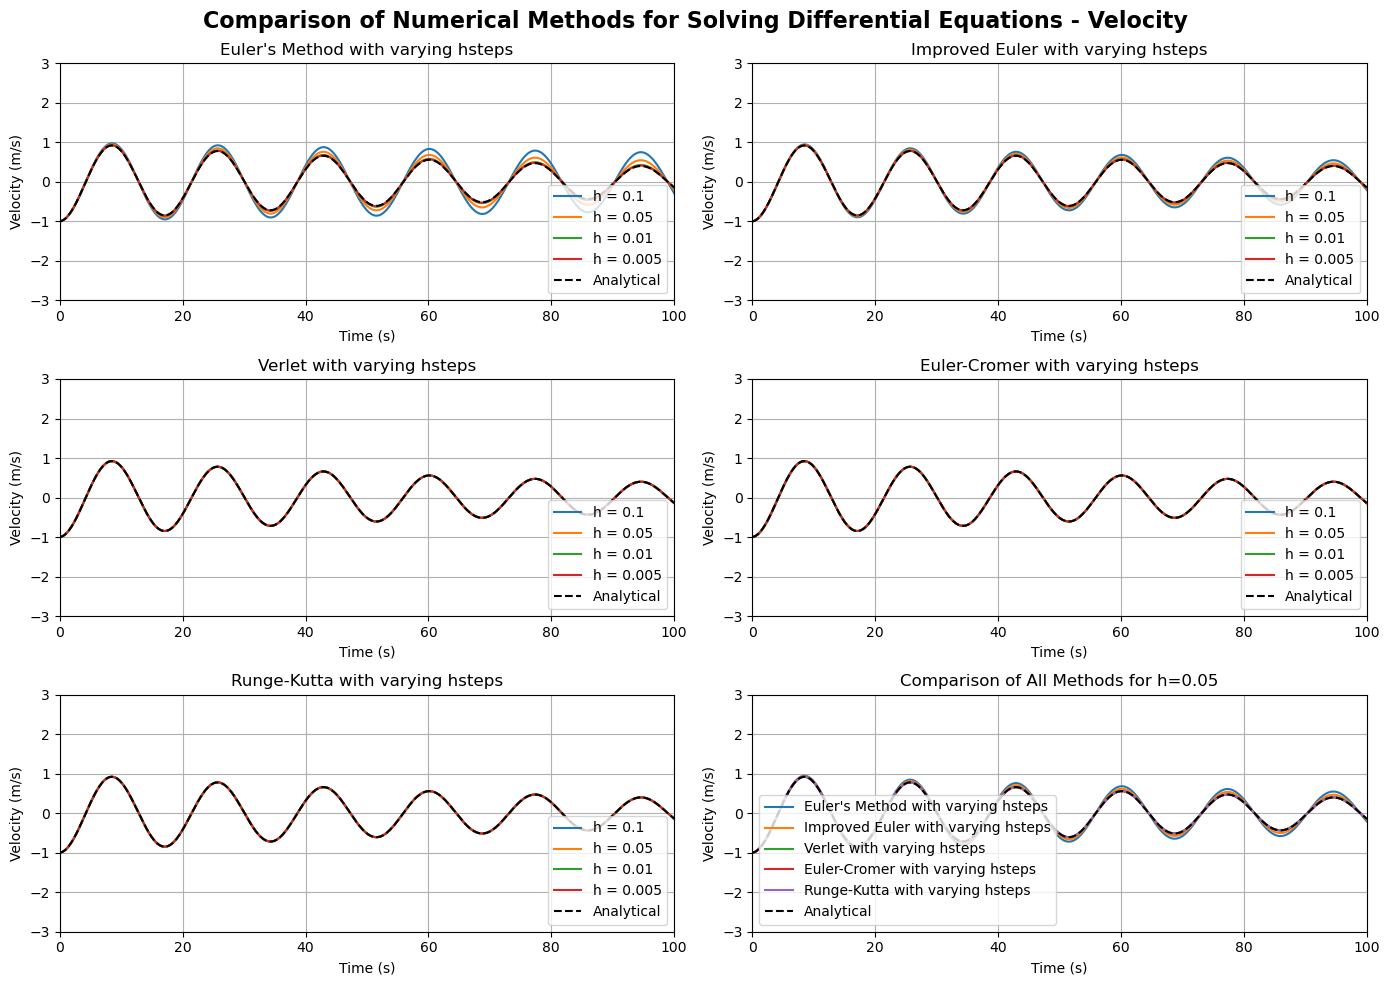

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))  #Setting the layout of the subplots, we will have 
axes = axes.flatten()  
h_values = [0.1, 0.05, 0.01, 0.005] #re-define the hsteps for making a new array 

time_arrays = {h: np.arange(0, T, h) for h in h_values}


methods = {
    "Euler's Method with varying hsteps": EulerMethod,
    "Improved Euler with varying hsteps": ImprovedEulerMethod,
    "Verlet with varying hsteps": VerletsMethod,
    "Euler-Cromer with varying hsteps": EulerCromer,
    "Runge-Kutta with varying hsteps": RK4_Method
}



# Generate and plot each method in its respective subplot
for i, (method_name, method) in enumerate(methods.items()):
    for hstep in h_values:
        nsteps = int(T / hstep)
        x, v, E = method(x0, v0, nsteps, hstep)
        axes[i].plot(np.arange(0, T, hstep), v, label=f"h = {hstep}")
        
        
    axes[i].plot(np.arange(0,T,hstep), Analytic_velocity(x0, v0, np.arange(0,T,hstep)).real, "k--", label = "Analytical")
    axes[i].set_title(method_name)
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Velocity (m/s)")
    axes[i].legend()
    axes[i].grid()
    axes[i].set_xlim(0, 100)
    axes[i].set_ylim(-3, 3)
    
ax_main = axes[-1]
hstep_main = 0.05
nsteps_main = int(T / hstep_main)

for method_name, method in methods.items():
    x, v, E = method(x0, v0, nsteps_main, hstep_main)
    ax_main.plot(time_arrays[hstep_main], v, label=f"{method_name}")

#Add analytical solution outside of initial for loop
ax_main.plot(time_arrays[hstep_main], 
             Analytic_velocity(x0, v0, time_arrays[hstep_main]).real, 
             "k--", label="Analytical")

ax_main.set_title("Comparison of All Methods for h=0.05")
ax_main.set_xlabel("Time (s)")
ax_main.set_ylabel("Velocity (m/s)")
ax_main.legend()
ax_main.set_xlim(0, 100)
ax_main.set_ylim(-3, 3)

#Formatting
fig.suptitle("Comparison of Numerical Methods for Solving Differential Equations - Velocity", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.grid()
plt.show()

The comparison of these plots indicate that Verlet, Euler Cromer and Runge Kutta are the most effective. This becomes even more visible in the comparison plot, where they are almost indistinguishable from the analytical solution. To find the best method, we will now consider energy.

### Comparing Energies

In a damped system as we considered above, the energy is meant to decrease as the system mechanically transfers energy to the surroundings. This transfer is smooth when considering it analytically, and the total energy follows an exponential decay. Below, each of the methods' energy decays will be shown in comparison to the analytical energy decay.

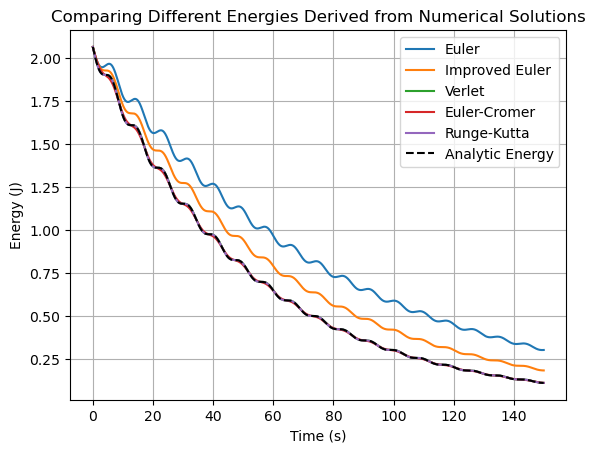

In [12]:
#plotting a graph with different energies
hstep = 0.05
nsteps = int(T / hstep)
xaxis = np.arange(0, T, hstep)

_, _, E_Euler = EulerMethod(x0, v0, nsteps, hstep)
_, _, E_Euler_Improved = ImprovedEulerMethod(x0, v0, nsteps, hstep)
_, _, E_Verlet = VerletsMethod(x0, v0, nsteps, hstep)
_, _, E_EulerCromer = EulerCromer(x0, v0, nsteps, hstep)
_, _, E_RK4 = RK4_Method(x0, v0, nsteps, hstep)


#Plotting all the methods
plt.plot(xaxis, E_Euler, label = 'Euler')
plt.plot(xaxis, E_Euler_Improved, label = 'Improved Euler')
plt.plot(xaxis, E_Verlet, label = 'Verlet')
plt.plot(xaxis, E_EulerCromer, label = 'Euler-Cromer')
plt.plot(xaxis, E_RK4, label = 'Runge-Kutta')
plt.plot(xaxis, Analytic_energy(x0, v0, xaxis).real, 'k--', label='Analytic Energy')

plt.title("Comparing Different Energies Derived from Numerical Solutions")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.grid()
plt.legend()

plt.show()


From this plot, Euler and Improved Euler methods are visibly different to the analytical solution. This plot will be zoomed in to see how the other three methods vary from the analytic solution.

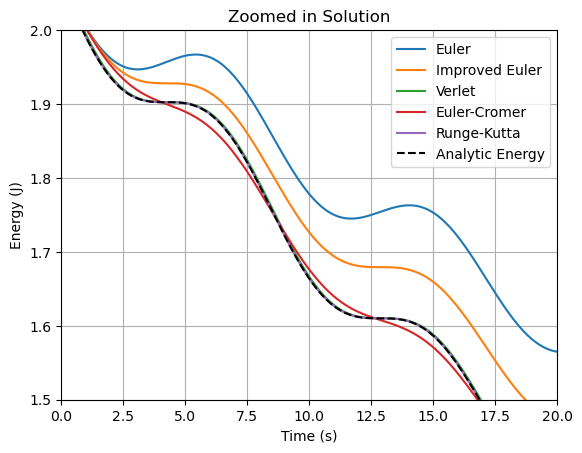

In [13]:
# Forming the solutions again
plt.plot(xaxis, E_Euler, label = 'Euler')
plt.plot(xaxis, E_Euler_Improved, label = 'Improved Euler')
plt.plot(xaxis, E_Verlet, label = 'Verlet')
plt.plot(xaxis, E_EulerCromer, label = 'Euler-Cromer')
plt.plot(xaxis, E_RK4, label = 'Runge-Kutta')
plt.plot(xaxis, Analytic_energy(x0, v0, xaxis).real, 'k--', label='Analytic Energy')

# Zooming into what is relevant
plt.xlim(0, 20)  # Focus on the first 20 seconds
plt.ylim(1.5, 2) 
plt.title("Zoomed in Solution")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.legend()
plt.grid()
plt.show()

Out of these 5 methods, Runge-Kutta and Verlet's method appear to be the most effective. However, the Runge-Kutta method is computationally slow and despite being similar in accuracy. Thus, for the rest of the project, the Verlet's Method will be used. 

## Comparing Damping Factors for Verlet's Method

Different values for b, the damping factor can be explored to see its effect on the system. The critical damping is defined as 

$$
    b_{critical} = 2 \sqrt{km} .
$$

When $b$ is above this, the system is overdamped, and when it is below, it is underdamped. The effects of changing this parameter will be seen on Verlet's method. 

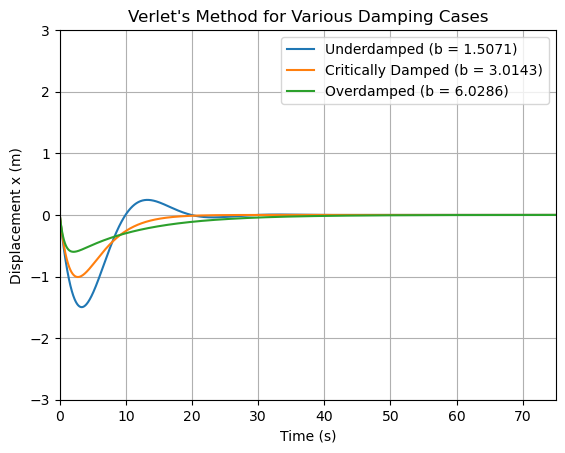

In [14]:
# Defining the critical damping value b_cr
b_critical = np.sqrt(4*k*m)

# Define damping values for underdamped, critically damped, and overdamped cases
B_array = [b_critical/2, b_critical, 2*b_critical]

# Writing Labels 
names = ["Underdamped", "Critically Damped", "Overdamped"]

#Timesteps
hstep = 0.005
nsteps = int(T / hstep)

#Performing verlet for the three damping cases
for b, name in zip(B_array, names):
    x, v, E = VerletsMethod(x0, v0, nsteps, hstep)  #Ensure VerletsMethod uses b
    plt.plot(np.arange(0, T, hstep), x, label=f'{name} (b = {b:.4f})')  # Updated label

# Plot settings
plt.legend()
plt.title("Verlet's Method for Various Damping Cases")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x (m)")
plt.xlim(0, 75)
plt.ylim(-3, 3)
plt.grid()

# Show the plot
plt.show()
plt.close()


This plot compares the effects of damping based on the parameter b being underdamped, critically damped and overdamped. We can see that when the system is underdamped, it undergoes an oscillation before coming to a rest. In comparison, an overdamped system reaches equilibrium slowly, but does not oscillate in the process. Finally, the critically damped system reaches equilbirum fastest out of the three.  

## Applying a Push 

When there is a force applied on such a system, the acceleration will change based on the force of the push. 
$$
   m \frac{d^2 x}{dt^2} + b \frac{dx}{dt} + kx = \frac{F}{m}
$$



This means that the Verlet Method has to be modified to account for this additional force. The code for Verlet's Method will no longer require considerations for energy, so the code will be adjusted accordingly. 

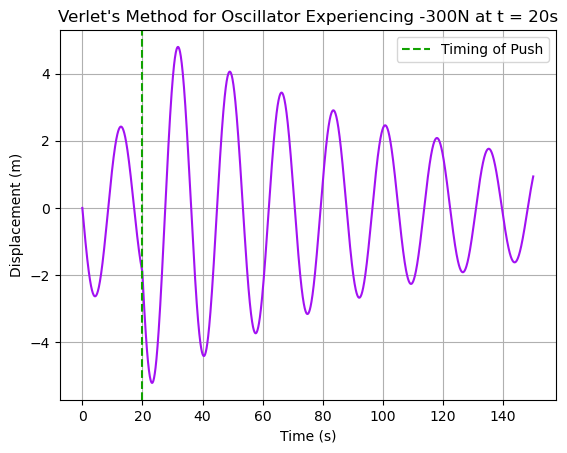

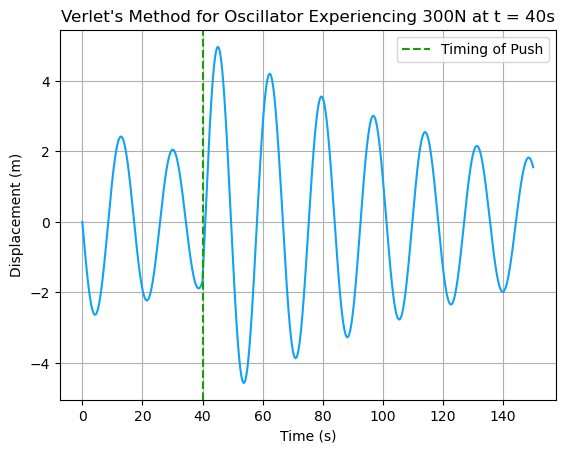

In [15]:
#We first precautionarily redefine variables.
final_h = 0.05
final_n = int(T/final_h)
time_array = np.linspace(0,T,final_n)
b = 0.08 

#The following defines Verlet's Method responding to a push
def VerletPushed(x0, v0, b, F, push_timing):
    # Create empty arrays ready for the values of x and v and initialise
    nsteps = final_n
    
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)
    
    x[0] = x0 
    v[0] = v0
    
    #We are concerned with the timing of the push, but for this, we consider it by index number.
    index = int(push_timing / final_h) - 1
    
    D = 2*m + final_h*b
    A = 2 * (2*m - k*final_h**2) / D
    B = (b*final_h - 2*m) / D
    
    for i in range(nsteps - 1):
    # Since Verlet requires an initial parameter to start, we separate based on what i is.
        if i == 0 or i == index:  # Handles both first step and push timing
            a = -(k/m) * x[i] - (b/m) * v[i] + (F/m if i == index else 0)
            x[i+1] = x[i] + v[i] * final_h + 0.5 * (final_h**2) * a  # in m
            v[i+1] = v[i] + a * final_h  # in m/s
        else:
            x[i+1] = A*x[i] + B*x[i-1]
            v[i] = (x[i+1] - x[i-1]) / (2*final_h)

    return (x, v)


# These will be the forces used
Force_1, Force_2 = -300, 300
Time_1, Time_2 = 20, 40

#Compute displacements for both force cases
push_1, _ = VerletPushed(x0, v0, b, Force_1, Time_1)
push_2, _ = VerletPushed(x0, v0, b, Force_2, Time_2)

#Plotting function
def plot_push_response(time_array, displacement, force, push_time, color, title):
    plt.plot(time_array, displacement, color=color)
    plt.axvline(x=push_time, color="#11A200", linestyle='--', label="Timing of Push")
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement (m)")
    plt.legend()
    plt.title(title)
    plt.grid()
    plt.show()


plot_push_response(time_array, 
                   push_1, 
                   Force_1, Time_1, 
                   "#A211F2", 
                   "Verlet's Method for Oscillator Experiencing -300N at t = 20s")

plot_push_response(time_array, 
                   push_2, 
                   Force_2, Time_2, 
                   "#11A2F2", 
                   "Verlet's Method for Oscillator Experiencing 300N at t = 40s")


These two plots show the effects of applying a force on a readily-oscillating system. A sudden change in the line is observed, and the next amplitude is significantly larger than that before. Based on the direction, the moment at which the maximum amplitude is observed changes. 

## Damped Driven Oscillator

The previous section explored what happens with a single push. Here, the effects of a repetitive push, i.e. a sinusoidal push will be explored. For this, the system will receive a force of $F(t) = F_0 cos(\omega t)$, which may be substituted into the equation for the sudden push. This requires another modification to the Verlet's method

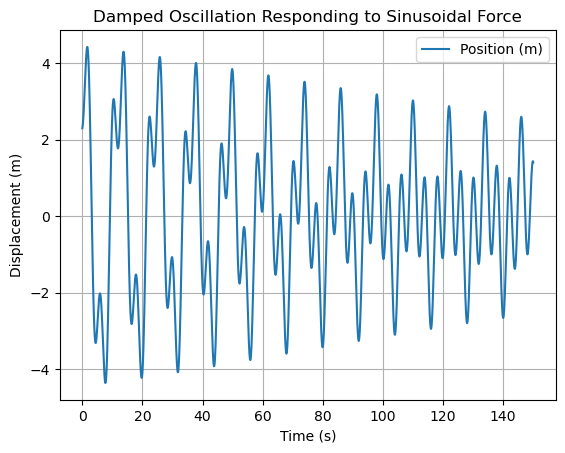

Final peak amplitude: 1.435 m


In [16]:
#Defining sinusoidal driving force
omega = np.pi / 2  # Arbitrary frequency in rad/s
F0 = 15  # N
Force = F0*np.cos(omega*time_array)  # Array of forces at each time step

#Acceleration function
def compute_acceleration(x, v, F_ext):
    return -(k/m) * x - (b/m) * v + (F_ext / m)

#Verlet response to driven oscillator
def VerletDriven(x0, v0, b, F):
    nsteps = final_n
    x = np.zeros(nsteps)
    v = np.zeros(nsteps)
    a = np.zeros(nsteps)
    
    # Initial conditions
    x[0], v[0] = x0, v0
    a[0] = compute_acceleration(x[0], v[0], F[0])

    #Constants
    D = 2*m + final_h*b
    A = 2 * (2*m - k*final_h**2) / D
    B = (b*final_h - 2*m) / D

   # Initial condition to start verlet before it can iterate on its own
    x[1] = x[0] + v[0] * final_h + 0.5 * (final_h**2) * a[0]
    v[1] = v[0] + a[0] * final_h

    # Verlet integration loop
    for i in range(1, nsteps - 1):  
        a[i] = compute_acceleration(x[i], v[i], F[i])
        x[i+1] = A * x[i] + B * x[i-1] + (final_h**2) * a[i]
        v[i] = (x[i+1] - x[i-1]) / (2 * final_h)  

    # Find peaks in the oscillation by using scipy's find_peaks function, obtain the index that the peak is at
    peaks = find_peaks(x, height=0)[0]  # Get peak indices
    final_peak_amplitude = x[peaks[-1]] if len(peaks) > 0 else None  #error check in case there was no peak

    return (x, v), final_peak_amplitude  # Return position, velocity, and final peak amplitude

#Calling the functions
(x_periodic, v_periodic), peak_amplitude = VerletDriven(2.3, 0.3, b, Force) #uses arbitrary values for x and v to start with

# Plot results
plt.plot(time_array, x_periodic, label="Position (m)")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Damped Oscillation Responding to Sinusoidal Force")
plt.legend()
plt.grid()
plt.show()

# Print peak amplitude if found
if peak_amplitude is not None:
    print(f"Final peak amplitude: {peak_amplitude:.3f} m")
else:
    print("No peaks found in oscillation.")


This plot shows that a sinusoidal force will cause a patterned but seemingly irregular displacement for the system. 

### Conclusion

This project investigated the four numerical methods, as well as a more computationally taxing method to solve the damped oscillator differential equations. Verlet's method was found to be the most accurate and practical, and this was implemented to observe how the system behaves under different damping coefficients and driving forces. The model behaves as expected analytically, and can be used to model real-life scenarios by changing different parameters.